# Decision Trees

#### Growing and Visualizing a Tree
##### Dataset: from sklearn.datasets import fetch_openml
##### Task: Train a Decision Tree classifier on a tabular dataset containing categorical and numerical data (like the Titanic dataset, after basic cleaning).
##### Action: Use sklearn.tree.plot_tree or export the model using graphviz to generate a visual flowchart of the tree. Trace the path of a specific passenger to see exactly why the model predicted they survived or died.

Accuracy: 0.7634
Prediction: Died
sex = 1.0 vs 0.50 -> RIGHT
age = 22.0 vs 9.50 -> RIGHT
pclass = 3.0 vs 1.50 -> RIGHT
LEAF -> Died


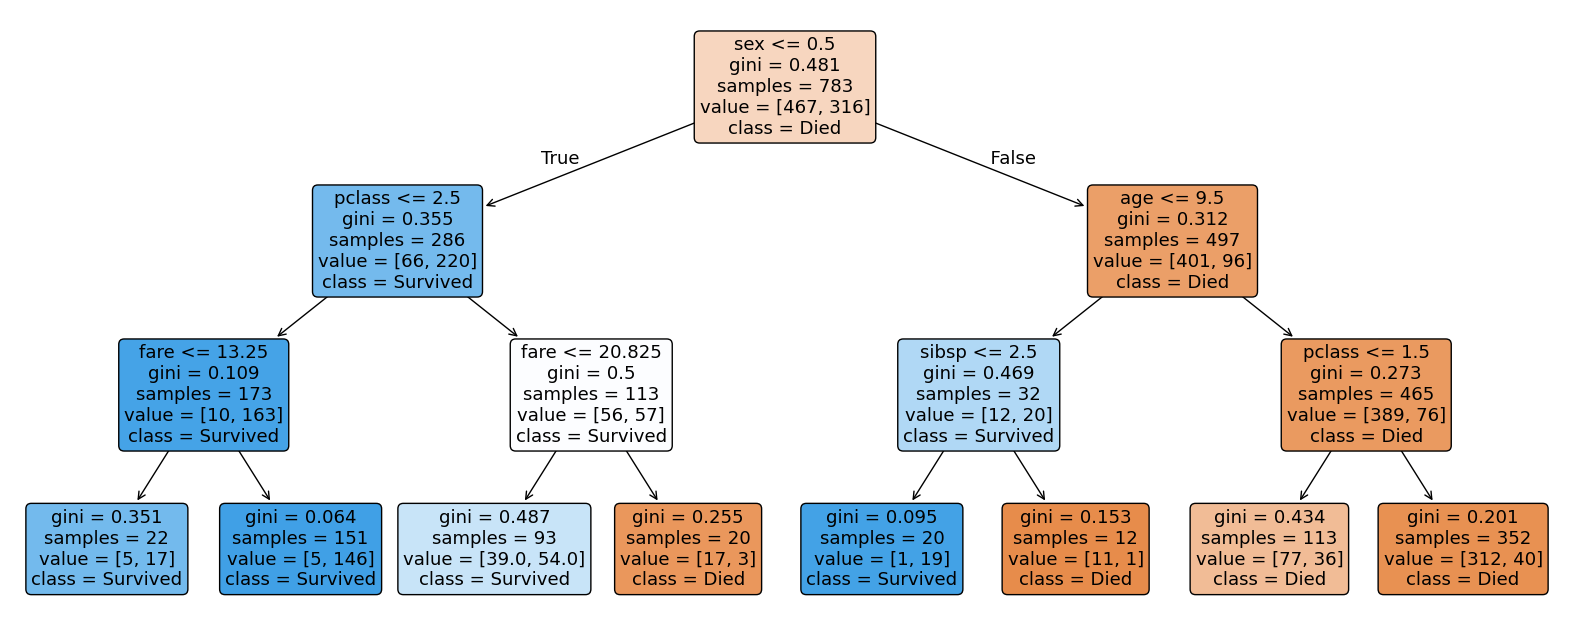

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import _tree

titanic = fetch_openml('titanic', version=1, as_frame=True)
df = titanic.frame[['pclass','sex','age','sibsp','parch','fare','survived']].dropna()
df['survived'] = df['survived'].astype(int)
df['sex'] = LabelEncoder().fit_transform(df['sex'])

X = df[['pclass','sex','age','sibsp','parch','fare']]
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)
print(f"Accuracy: {clf.score(X_test, y_test):.4f}")

plt.figure(figsize=(20, 8))
plot_tree(clf, feature_names=X.columns, class_names=["Died","Survived"], filled=True, rounded=True)
plt.savefig("tree.png", dpi=150)

passenger = pd.DataFrame([[3, 1, 22, 0, 0, 7.25]], columns=X.columns)
pred = clf.predict(passenger)[0]
print(f"Prediction: {'Survived' if pred else 'Died'}")

t = clf.tree_
for node in clf.decision_path(passenger).indices:
    if t.feature[node] == _tree.TREE_UNDEFINED:
        print(f"LEAF -> {'Survived' if pred else 'Died'}")
    else:
        feat, thresh, val = X.columns[t.feature[node]], t.threshold[node], float(passenger.iloc[0, t.feature[node]])
        print(f"{feat} = {val} vs {thresh:.2f} -> {'LEFT' if val <= thresh else 'RIGHT'}")

#### Pruning and Overfitting Mitigation
##### Dataset: from sklearn.datasets import fetch_openml
##### Task: Decision trees naturally overfit. Train an unconstrained decision tree on a complex dataset and note the training accuracy (often 100%) vs. test accuracy.
##### Action: Experiment with hyperparameter tuning to "prune" the tree. Specifically, tweak max_depth, min_samples_split, and min_samples_leaf. Find the combination that reduces the gap between training and test accuracy, yielding a more generalized model.

In [3]:
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

titanic = fetch_openml('titanic', version=1, as_frame=True)
df = titanic.frame[['pclass','sex','age','sibsp','parch','fare','survived']].dropna()
df['survived'] = df['survived'].astype(int)
df['sex'] = LabelEncoder().fit_transform(df['sex'])

X = df[['pclass','sex','age','sibsp','parch','fare']]
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)
print(f"Unconstrained -> Train: {clf.score(X_train, y_train):.4f} | Test: {clf.score(X_test, y_test):.4f}")

configs = [
    {'max_depth': 3,  'min_samples_split': 2,  'min_samples_leaf': 1},
    {'max_depth': 4,  'min_samples_split': 10, 'min_samples_leaf': 5},
    {'max_depth': 5,  'min_samples_split': 20, 'min_samples_leaf': 10},
    {'max_depth': 6,  'min_samples_split': 30, 'min_samples_leaf': 15},
    {'max_depth': 10, 'min_samples_split': 5,  'min_samples_leaf': 2},
]

print("\nPruned models:")
print(f"{'max_depth':<12} {'min_split':<12} {'min_leaf':<12} {'Train':<10} {'Test':<10} {'Gap'}")
print("-" * 65)
for cfg in configs:
    m = DecisionTreeClassifier(**cfg, random_state=42)
    m.fit(X_train, y_train)
    train_acc = m.score(X_train, y_train)
    test_acc  = m.score(X_test, y_test)
    gap = train_acc - test_acc
    print(f"{cfg['max_depth']:<12} {cfg['min_samples_split']:<12} {cfg['min_samples_leaf']:<12} {train_acc:<10.4f} {test_acc:<10.4f} {gap:.4f}")

Unconstrained -> Train: 0.9821 | Test: 0.7405

Pruned models:
max_depth    min_split    min_leaf     Train      Test       Gap
-----------------------------------------------------------------
3            2            1            0.8340     0.7634     0.0706
4            10           5            0.8391     0.7710     0.0681
5            20           10           0.8416     0.7672     0.0745
6            30           15           0.8340     0.7634     0.0706
10           5            2            0.8940     0.7328     0.1612
